In [2]:
# ========================================================
# HEART STROKE PREDICTION - CNN-LSTM MODEL
# ========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

In [6]:
# --------------------------------------------------------
# 1. Load and Preprocess Data
# --------------------------------------------------------
data = pd.read_csv("C:/Users/Lenovo/Downloads/archive/healthcare-dataset-stroke-data.csv")

# Drop unnecessary columns
if 'id' in data.columns:
    data.drop('id', axis=1, inplace=True)

# Fill missing BMI values
data['bmi'].fillna(data['bmi'].median(), inplace=True)

# Remove rare category in gender
data = data[data['gender'] != 'Other']

# Encode categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Features and target
X = data.drop('stroke', axis=1).values
y = data['stroke'].values

In [7]:
# --------------------------------------------------------
# 2. Train-Test Split + SMOTE Balancing
# --------------------------------------------------------
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Scale data
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_full, y_train_full)

# Reshape data for CNN-LSTM
X_train_dl = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_dl = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_dl = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

y_train_dl = to_categorical(y_train)
y_val_dl = to_categorical(y_val)
y_test_dl = to_categorical(y_test)

In [8]:
# --------------------------------------------------------
# 3. Build CNN-LSTM Model
# --------------------------------------------------------
model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train_dl.shape[1], 1)),
    MaxPooling1D(2),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 8, 64)               │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 4, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,570 (146.76 KB)

 Trainable params: 37,570 (146.76 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# --------------------------------------------------------
# 4. Train Model
# --------------------------------------------------------
history = model.fit(
    X_train_dl, y_train_dl,
    epochs=25,
    batch_size=32,
    validation_data=(X_val_dl, y_val_dl),
    verbose=1
)

Epoch 1/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7168 - loss: 0.5465 - val_accuracy: 0.6149 - val_loss: 0.5944
Epoch 2/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7682 - loss: 0.4800 - val_accuracy: 0.6580 - val_loss: 0.4935
Epoch 3/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7804 - loss: 0.4707 - val_accuracy: 0.6319 - val_loss: 0.5648
Epoch 4/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7825 - loss: 0.4584 - val_accuracy: 0.6514 - val_loss: 0.4819
Epoch 5/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7926 - loss: 0.4491 - val_accuracy: 0.6684 - val_loss: 0.5115
Epoch 6/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7925 - loss: 0.4451 - val_accuracy: 0.6893 - val_loss: 0.4851
Epoch 7/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7970 - loss: 0.4378 - val_accuracy: 0.7272 - val_loss: 0.4136
Epoch 8/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8020 - loss: 0.4274 - val_accuracy: 0.

In [10]:
# --------------------------------------------------------
# 5. Evaluate Model
# --------------------------------------------------------
cnn_lstm_pred = np.argmax(model.predict(X_test_dl, verbose=0), axis=1)
acc = accuracy_score(y_test, cnn_lstm_pred)
print(f"\n✅ CNN-LSTM Model Accuracy: {acc*100:.2f}%")


✅ CNN-LSTM Model Accuracy: 76.01%


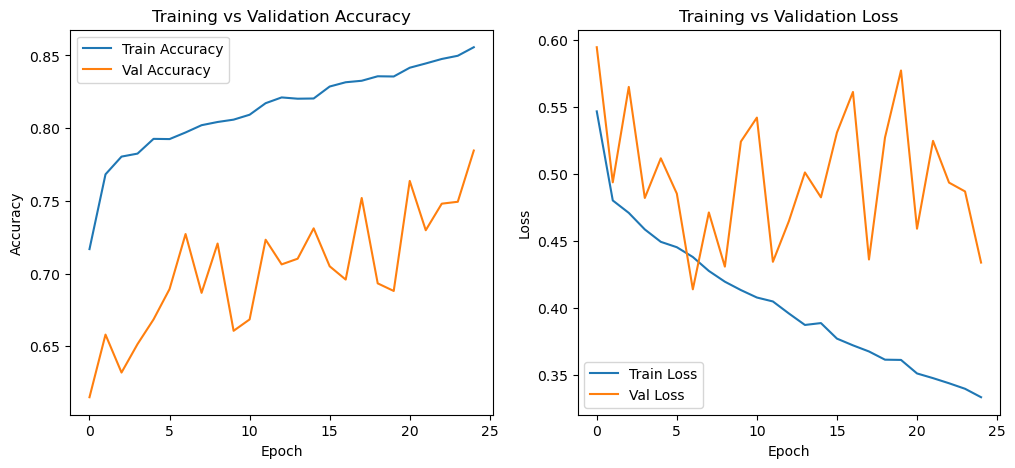

In [11]:
# --------------------------------------------------------
# 7. Plot Accuracy and Loss
# --------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

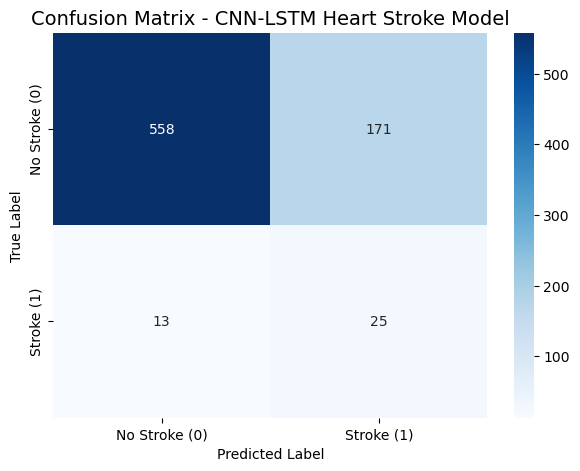


Classification Report - CNN-LSTM Heart Stroke Model:
               precision    recall  f1-score   support

No Stroke (0)       0.98      0.77      0.86       729
   Stroke (1)       0.13      0.66      0.21        38

     accuracy                           0.76       767
    macro avg       0.55      0.71      0.54       767
 weighted avg       0.94      0.76      0.83       767



In [12]:
# --------------------------------------------------------
# 6. Confusion Matrix + Classification Report
# --------------------------------------------------------
cm = confusion_matrix(y_test, cnn_lstm_pred)
class_labels = ['No Stroke (0)', 'Stroke (1)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - CNN-LSTM Heart Stroke Model', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report - CNN-LSTM Heart Stroke Model:")
print(classification_report(y_test, cnn_lstm_pred, target_names=class_labels, zero_division=0))